# ESSE method implementation - test notebook

In [27]:
import matplotlib.pyplot as plt
import torch # needed for kernels
import numpy as np
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.transforms.shared import GaussianFilter
from pytomography.io.SPECT.shared import subsample_projections_and_modify_metadata
import os
from pytomography.utils import plot_utils, ESSEScatterModel, pad_object

from pytomography.projectors.SPECT.dualhead_system_matrix import SPECTSystemMatrix

In [28]:
path = 'K:\\Médecine Nucléaire Nantes\\DOSSIERS Nominatif PHYSICIENS\\Etudiants\\Chloé_Mallet_M2_2026\\SPECT'
pathCT = os.path.join(path, 'Lu177-NEMA-SymT2', 'CT')
# pathCT = os.path.join(path, 'Ac225-NEMA-SymT2', 'CT')
files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]
file_NM = os.path.join(path, 'Lu177-NEMA-SymT2', 'projection_data.dcm')
# file_NM = os.path.join(path, 'Ac225-NEMA-SymT2', 'projection_data.IMA')

current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [29]:
energy = 208.0

nb_iter=15
nb_subset=8

In [30]:
object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = dicom.get_projections(file_NM)
attenuation_map = dicom.get_attenuation_map_from_CT_slices(files_CT, file_NM)
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)


Given photopeak energy 208.0 keV and CT energy 130 keV from the CT DICOM header, the HU->mu conversion from the following configuration is used: 208.0 keV SPECT energy, 130 keV CT energy, and scanner model symbiat2


In [31]:
projections.shape
proj_meta

att_transform = SPECTAttenuationTransform(attenuation_map=attenuation_map)
collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=object_meta.dx
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

In [32]:
# todo : Récupérer les kernels ESSE réels quand j'aurai accès au code dicom
def get_fake_esse_kernels(grid_size):
    """
    Génère des kernels gaussiens avec la bonne taille.
    """
    Z, Y, X = grid_size
    kernels = torch.zeros((3, Z, Y, X))
  
    sigmas = [2.0, 2.0, 2.0] #écart type en nombre de voxels, pour chacun des noyaux
  
    for i, sigma in enumerate(sigmas):
        z = torch.arange(Z, dtype=torch.float32) - Z // 2
        y = torch.arange(Y, dtype=torch.float32) - Y // 2
        x = torch.arange(X, dtype=torch.float32) - X // 2
      
        zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')
        distance_sq = zz**2 + yy**2 + xx**2     # en unités de voxels
        kernels[i] = torch.exp(-distance_sq / (2 * sigma**2))
      
        kernels[i] /= kernels[i].sum()
  
    return kernels * 0.009

# def get_fake_esse_kernels(grid_size):
#     """
#     Génère des kernels Delta (impulsions) au centre exact de la grille.
#     """
#     Z, Y, X = grid_size
#     kernels = torch.zeros((3, Z, Y, X))
    
#     cz, cy, cx = Z // 2, Y // 2, X // 2
    
#     # On place la valeur 1.0 au centre de chaque noyau
#     # La somme est déjà de 1.0, donc pas besoin de normaliser
#     kernels[:, cz, cy, cx] = 1.0
    
#     return kernels

# Obtenir la taille réelle de l'objet padded
test_object = pad_object(torch.zeros(object_meta.shape))
padded_shape = test_object.shape

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_fake_esse_kernels(
        grid_size=object_meta.padded_shape,
    )
)

system_matrix = SPECTSystemMatrix(
                obj2obj_transforms = [att_transform, psf_transform],
        proj2proj_transforms = [],
        object_meta = object_meta,
        proj_meta = proj_meta,
        scatter_model=esse
        )

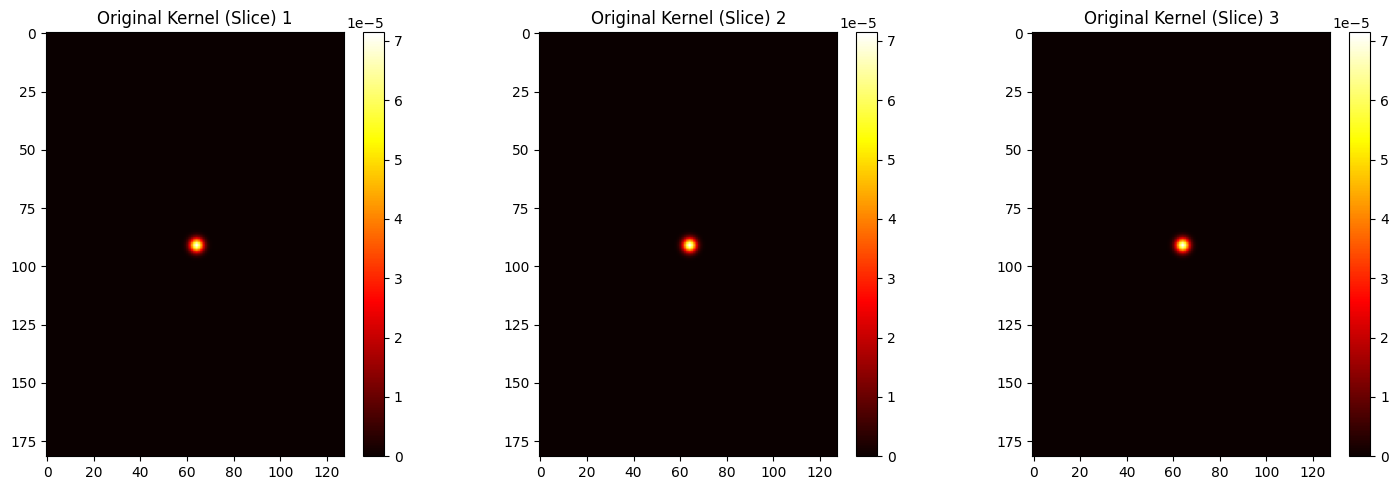

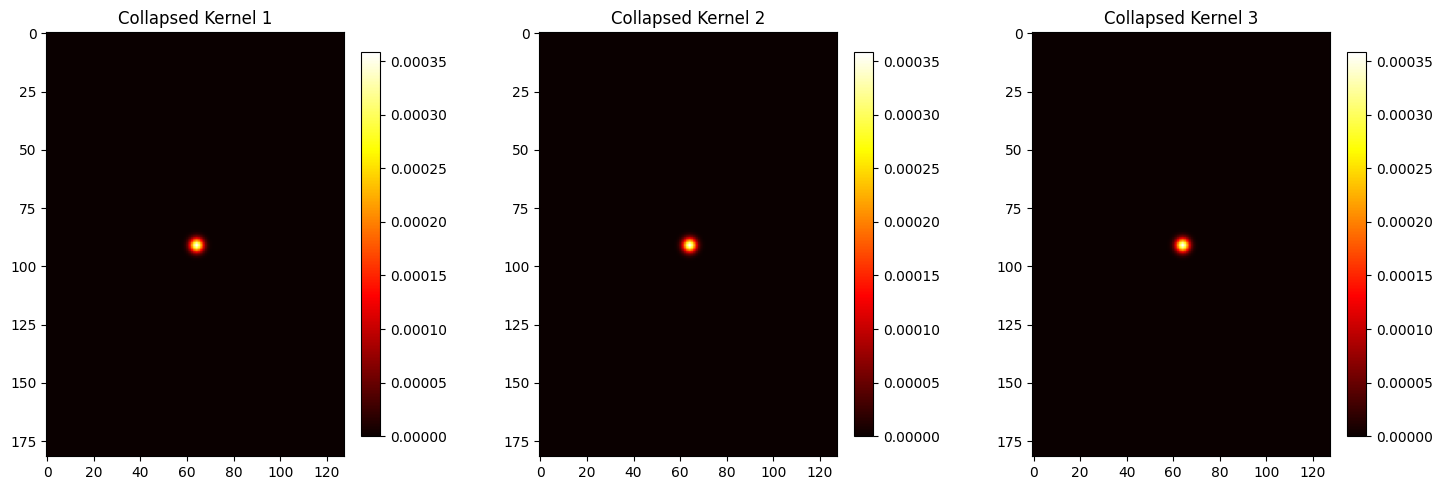

Somme Originale: 9.00e-03
Somme Collapsed: 9.00e-03


In [33]:

kernels = get_fake_esse_kernels(grid_size=padded_shape)


collapsed_kernels = kernels.sum(dim=1) 

def plot_kernels(data, title_prefix, cmap='hot'):
    num_channels = data.shape[0]
    fig, axes = plt.subplots(1, num_channels, figsize=(5 * num_channels, 5))
    if num_channels == 1: axes = [axes]
    
    for i in range(num_channels):
        img = data[i, data.shape[1]//2] if data.ndim == 4 else data[i]
        im = axes[i].imshow(img.detach().cpu().numpy(), cmap=cmap)
        axes[i].set_title(f'{title_prefix} {i+1}')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Affichage des deux états
plot_kernels(kernels, "Original Kernel (Slice)")
plot_kernels(collapsed_kernels, "Collapsed Kernel")

print(f"Somme Originale: {kernels[0].sum().item():.2e}")
print(f"Somme Collapsed: {collapsed_kernels[0].sum().item():.2e}")

In [34]:
index_peak = 0
photopeak = dicom.get_projections(file_NM, index_peak=index_peak)
likelihood = PoissonLogLikelihood(system_matrix, photopeak)
algorithm = OSEM(likelihood)

In [35]:
recon = algorithm(n_iters=nb_iter, n_subsets=nb_subset)


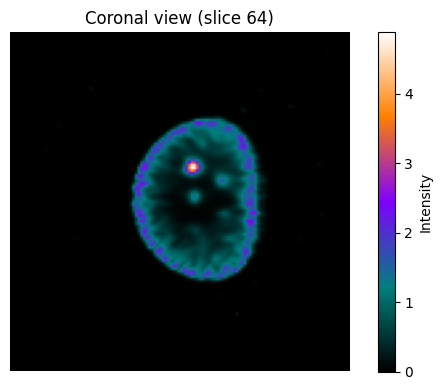

Reconstruction affichée au slice z=64
Range de valeurs: [0.000, 25.511]


In [36]:
# Plot un peu plus logique par rapport aux vraies dimensions des données

CT = dicom.open_multifile(files_CT)
affine_SPECT = dicom._get_affine_spect_projections(file_NM)
affine_CT = dicom._get_affine_multifile(files_CT)

recon_max = recon.max().item()
recon_min = recon.min().item()

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 0.6,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}
CT_imshow_kwargs = {
    'cmap': 'Greys_r',
    'interpolation': 'Gaussian',
    'vmin': -25,  # HU
    'vmax': 300,  # HU
    'zorder': 0,
    'origin': 'lower'
}

slice_idx = recon.shape[-1] // 2

plt.figure(figsize=(6, 4))
plt.title(f'Coronal view (slice {slice_idx})')
plt.imshow(recon[:, :, slice_idx], cmap=plot_utils.pet_cmap, origin='lower')
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Reconstruction affichée au slice z={slice_idx}")
print(f"Range de valeurs: [{recon_min:.3f}, {recon_max:.3f}]")

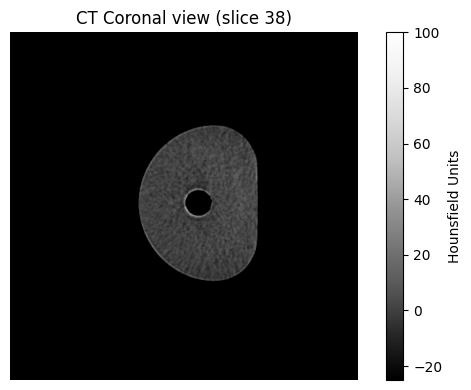

CT affichée au slice z=38
Range de valeurs CT: [-1024.0, 450.0] HU


In [37]:
# Affichage de la vue coronale en CT

slice_idx = CT.shape[-1] // 2

plt.figure(figsize=(6, 4))
plt.title(f'CT Coronal view (slice {slice_idx})')
plt.imshow(CT[:, :, slice_idx], cmap='Greys_r', origin='lower', vmin=-25, vmax=100)
plt.colorbar(label='Hounsfield Units')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"CT affichée au slice z={slice_idx}")
print(f"Range de valeurs CT: [{CT.min():.1f}, {CT.max():.1f}] HU")

In [38]:
# Reconstruction SANS ESSE pour comparaison

system_matrix_no_esse = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta,
    scatter_model=None  # PAS de ESSE
)

likelihood_no_esse = PoissonLogLikelihood(system_matrix_no_esse, photopeak)
algorithm_no_esse = OSEM(likelihood_no_esse)
recon_no_esse = algorithm_no_esse(n_iters=nb_iter, n_subsets=nb_subset)

print(f"Reconstruction sans ESSE - Min: {recon_no_esse.min():.3f}, Max: {recon_no_esse.max():.3f}")


Reconstruction sans ESSE - Min: 0.000, Max: 31.470


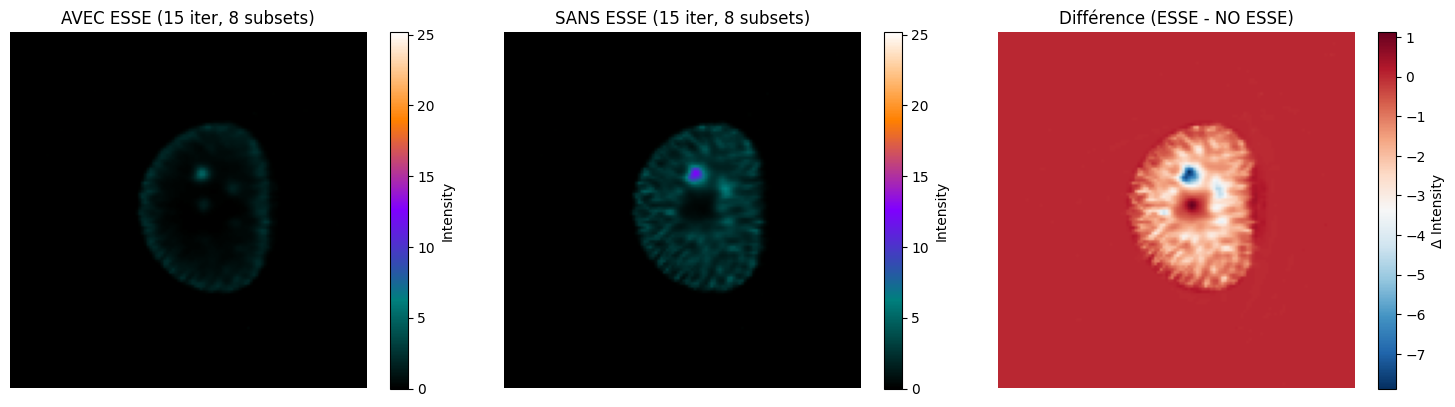


=== Comparaison AVEC vs SANS ESSE ===
AVEC ESSE  - Mean: 0.038, Std: 0.230, Max: 25.511
SANS ESSE  - Mean: 0.096, Std: 0.492, Max: 31.470
Différence - Mean abs: 0.061, Max abs: 11.140
% de différence (relative au max): 43.7%


In [39]:

# Comparaison visuelle : AVEC vs SANS ESSE

slice_idx = recon.shape[-1] // 2
vmax_comum = max(recon.max().item(), recon_no_esse.max().item()) * 0.8

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# AVEC ESSE
im1 = axes[0].imshow(recon[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_comum, origin='lower')
axes[0].set_title(f'AVEC ESSE ({nb_iter} iter, {nb_subset} subsets)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Intensity')

# SANS ESSE
im2 = axes[1].imshow(recon_no_esse[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_comum, origin='lower')
axes[1].set_title(f'SANS ESSE ({nb_iter} iter, {nb_subset} subsets)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Intensity')

# DIFFÉRENCE
diff = recon - recon_no_esse
im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower')
axes[2].set_title('Différence (ESSE - NO ESSE)')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

plt.tight_layout()
plt.show()

# Statistiques
print(f"\n=== Comparaison AVEC vs SANS ESSE ===")
print(f"AVEC ESSE  - Mean: {recon.mean():.3f}, Std: {recon.std():.3f}, Max: {recon.max():.3f}")
print(f"SANS ESSE  - Mean: {recon_no_esse.mean():.3f}, Std: {recon_no_esse.std():.3f}, Max: {recon_no_esse.max():.3f}")
print(f"Différence - Mean abs: {diff.abs().mean():.3f}, Max abs: {diff.abs().max():.3f}")
print(f"% de différence (relative au max): {(diff.abs().max() / recon.max() * 100):.1f}%")


In [40]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# On définit les sliders séparément pour mieux les configurer
slider_x = IntSlider(min=0, max=recon.shape[0]-1, step=1, value=recon.shape[0]//2, continuous_update=False)
slider_y = IntSlider(min=0, max=recon.shape[1]-1, step=1, value=recon.shape[1]//2, continuous_update=False)
slider_z = IntSlider(min=0, max=recon.shape[2]-1, step=1, value=recon.shape[2]//2, continuous_update=False)

def plot_interactive_spect(x, y, z):
    # Création de la figure
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    
    # Prétitres pour plus de clarté
    rows = ['SPECT ESSE', 'SPECT no ESSE', 'Différence']
    
    # 1. SPECT AVEC ESSE
    axes[0, 0].imshow(recon[:, :, z], cmap=plot_utils.pet_cmap, origin='lower', vmin=recon_min, vmax=recon_max * 0.8)
    axes[0, 1].imshow(recon[:, y, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=recon_min, vmax=recon_max * 0.8)
    axes[0, 2].imshow(recon[x, :, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=recon_min, vmax=recon_max * 0.8)

    # 2. SPECT SANS ESSE
    axes[1, 0].imshow(recon_no_esse[:, :, z], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax_comum)
    axes[1, 1].imshow(recon_no_esse[:, y, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax_comum)
    axes[1, 2].imshow(recon_no_esse[x, :, :], cmap=plot_utils.pet_cmap, origin='lower', vmin=0, vmax=vmax_comum)

    # 3. DIFFÉRENCE
    diff = recon - recon_no_esse
    axes[2, 0].imshow(diff[:, :, z], cmap='RdBu_r', origin='lower')
    axes[2, 1].imshow(diff[:, y, :], cmap='RdBu_r', origin='lower')
    axes[2, 2].imshow(diff[x, :, :], cmap='RdBu_r', origin='lower')

    # Titres des colonnes
    axes[0, 0].set_title(f'Axial (z={z})')
    axes[0, 1].set_title(f'Coronal (y={y})')
    axes[0, 2].set_title(f'Sagittal (x={x})')

    # Titres des lignes
    for i in range(3):
        axes[i, 0].set_ylabel(rows[i], fontsize=12)

    # Nettoyage
    for ax in axes.flatten():
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Lancement de l'interface
interact(plot_interactive_spect, x=slider_x, y=slider_y, z=slider_z)

interactive(children=(IntSlider(value=64, continuous_update=False, description='x', max=127), IntSlider(value=…

<function __main__.plot_interactive_spect(x, y, z)>

In [41]:
# Tester une reconstruction pytomography avec TEW comme modèle de diffusion, pour comparer avec ESSE
index_peak, index_lower, index_upper = 1, 0, 2
scatter_TEW = dicom.get_energy_window_scatter_estimate_projections(file_NM, projections, index_peak=index_peak, index_lower=index_lower, index_upper=index_upper, sigma_theta=2, sigma_r=0.48, sigma_z=0.48, proj_meta=proj_meta)

In [42]:


system_matrix_TEW = SPECTSystemMatrix(
        obj2obj_transforms = [att_transform, psf_transform],
        proj2proj_transforms = [],
        object_meta = object_meta,
        proj_meta = proj_meta)

likelihood_TEW = PoissonLogLikelihood(system_matrix_TEW, photopeak, scatter_TEW)
algorithm_TEW = OSEM(likelihood_TEW)

In [43]:
recon_TEW = algorithm_TEW(n_iters=nb_iter, n_subsets=nb_subset)


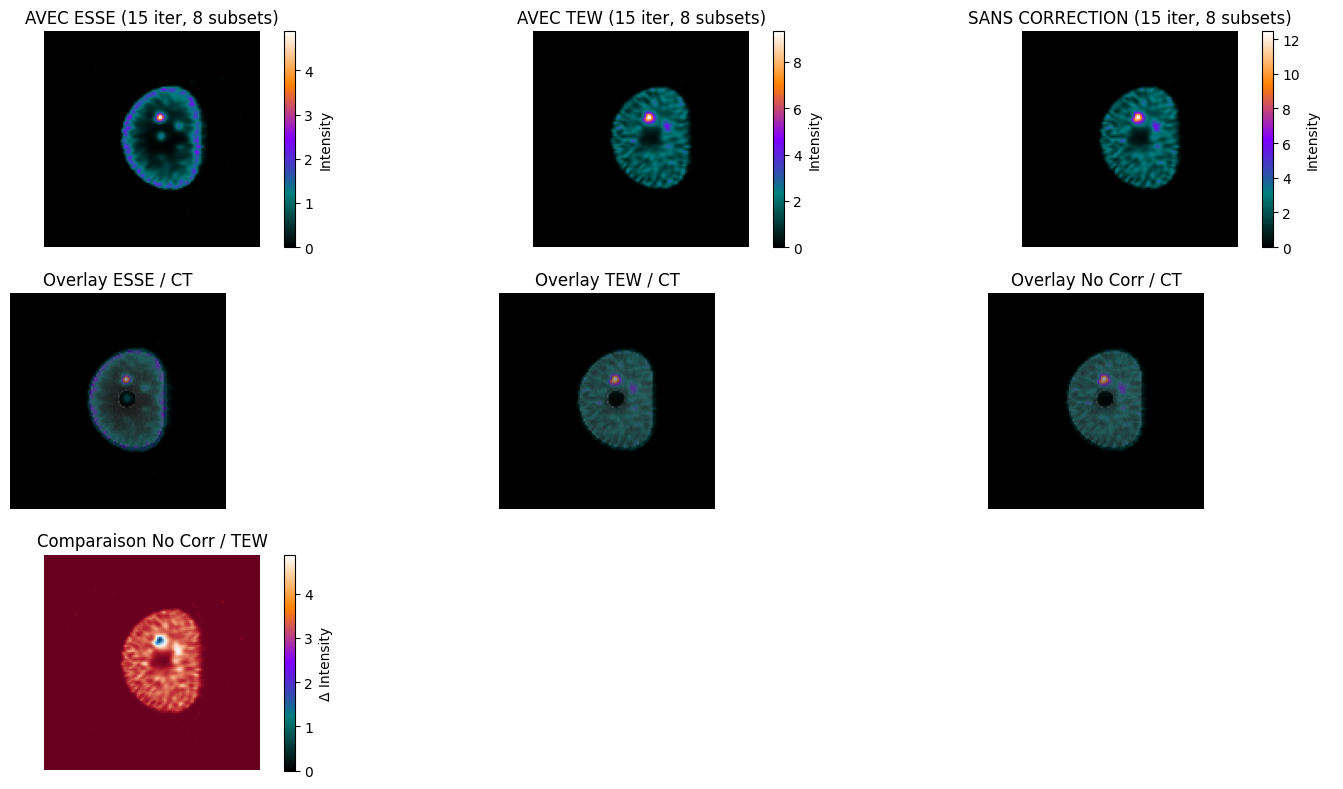

In [44]:
ct_tensor = CT.float().unsqueeze(0).unsqueeze(0) 

ct_resampled = torch.nn.functional.interpolate(ct_tensor, size=(128, 128, 128), mode='trilinear', align_corners=False)
CT_128 = ct_resampled.squeeze().numpy() # Pour l'affichage Matplotlib

# Conversion des SPECT en numpy pour l'affichage si ce sont des Tensors
esse_np = recon.detach().cpu().numpy() if torch.is_tensor(recon) else recon
tew_np = recon_TEW.detach().cpu().numpy() if torch.is_tensor(recon_TEW) else recon_TEW
no_corr_np = recon_no_esse.detach().cpu().numpy() if torch.is_tensor(recon_no_esse) else recon_no_esse

slice_idx = 64 
vmax_spect = max(esse_np.max(), tew_np.max()) * 0.8

fig, axes = plt.subplots(3, 3, figsize=(15, 8))

# --- LIGNE 1 : SPECT SEUL ---
# AVEC ESSE
im1 = axes[0, 0].imshow(recon[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, origin='lower')
axes[0, 0].set_title(f'AVEC ESSE ({nb_iter} iter, {nb_subset} subsets)')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], label='Intensity')

# AVEC TEW
im2 = axes[0, 1].imshow(recon_TEW[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, origin='lower')
axes[0, 1].set_title(f'AVEC TEW ({nb_iter} iter, {nb_subset} subsets)')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], label='Intensity')

# SANS CORRECTION
im3 = axes[0, 2].imshow(recon_no_esse[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, origin='lower')
axes[0, 2].set_title(f'SANS CORRECTION ({nb_iter} iter, {nb_subset} subsets)')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], label='Intensity')

# --- LIGNE 3 : OVERLAY (SPECT SUR CT) ---
# Overlay ESSE
axes[1, 0].imshow(CT_128[:, :, slice_idx], cmap='Greys_r', vmin=-25, vmax=100, origin='lower')
axes[1, 0].imshow(esse_np[:, :, slice_idx], cmap=plot_utils.pet_cmap, alpha=0.5, vmin=0, origin='lower')
axes[1, 0].set_title('Overlay ESSE / CT')

# Overlay TEW
axes[1, 1].imshow(CT_128[:, :, slice_idx], cmap='Greys_r', vmin=-25, vmax=100, origin='lower')
axes[1, 1].imshow(tew_np[:, :, slice_idx], cmap=plot_utils.pet_cmap, alpha=0.5, vmin=0, origin='lower')
axes[1, 1].set_title('Overlay TEW / CT')

# Overlay Sans Correction
axes[1, 2].imshow(CT_128[:, :, slice_idx], cmap='Greys_r', vmin=-25, vmax=100, origin='lower')
axes[1, 2].imshow(no_corr_np[:, :, slice_idx], cmap=plot_utils.pet_cmap, alpha=0.5, origin='lower')
axes[1, 2].set_title('Overlay No Corr / CT')

diff = recon_TEW - recon_no_esse
axes[2, 0].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower')
axes[2, 0].set_title('Comparaison No Corr / TEW')
axes[2, 0].axis('off')
plt.colorbar(im1, ax=axes[2, 0], label='Δ Intensity')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

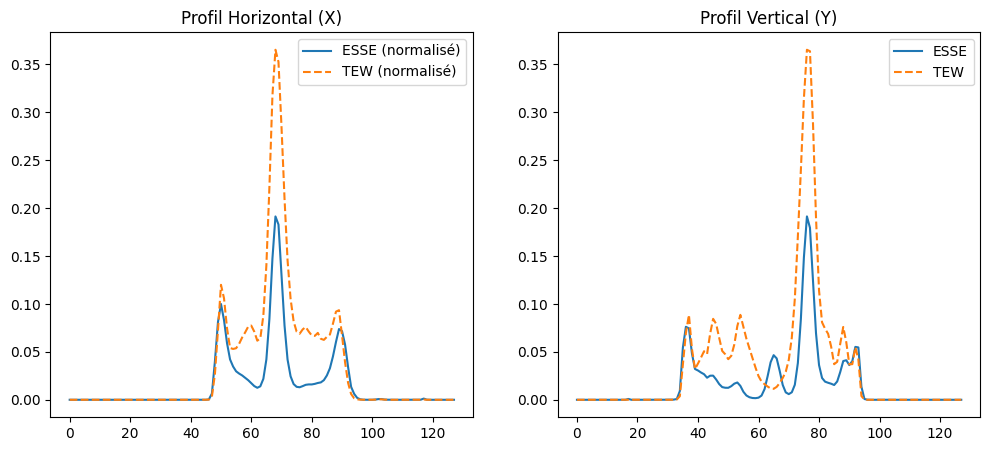

Max ESSE en : (np.int64(76), np.int64(68))
Max TEW en  : (np.int64(76), np.int64(68))


In [45]:

import numpy as np

# Trouver le pixel maximum pour ESSE et TEW
coords_esse = np.unravel_index(np.argmax(recon[:, :, slice_idx]), recon[:, :, slice_idx].shape)
coords_tew = np.unravel_index(np.argmax(recon_TEW[:, :, slice_idx]), recon_TEW[:, :, slice_idx].shape)

plt.figure(figsize=(12, 5))

# Profil horizontal (X)
plt.subplot(1, 2, 1)
plt.plot(recon[coords_esse[0], :, slice_idx] / recon.max(), label='ESSE (normalisé)')
plt.plot(recon_TEW[coords_tew[0], :, slice_idx] / recon_TEW.max(), label='TEW (normalisé)', linestyle='--')
plt.title('Profil Horizontal (X)')
plt.legend()

# Profil vertical (Y)
plt.subplot(1, 2, 2)
plt.plot(recon[:, coords_esse[1], slice_idx] / recon.max(), label='ESSE')
plt.plot(recon_TEW[:, coords_tew[1], slice_idx] / recon_TEW.max(), label='TEW', linestyle='--')
plt.title('Profil Vertical (Y)')
plt.legend()

plt.show()

print(f"Max ESSE en : {coords_esse}")
print(f"Max TEW en  : {coords_tew}")

## Test modèle ESSE avec CGSM (Coarse Grid Scatter Modelling)

In [46]:
esseCGSM = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_fake_esse_kernels(
        grid_size=padded_shape,
    ),
    CGSM=2
)

system_matrixCGSM = SPECTSystemMatrix(
        obj2obj_transforms = [att_transform, psf_transform],
        proj2proj_transforms = [],
        object_meta = object_meta,
        proj_meta = proj_meta,
        scatter_model=esseCGSM  
        )

likelihoodCGSM = PoissonLogLikelihood(system_matrixCGSM, photopeak)
algorithmCGSM = OSEM(likelihoodCGSM)


In [47]:
reconCGSM = algorithmCGSM(n_iters=nb_iter, n_subsets=nb_subset)

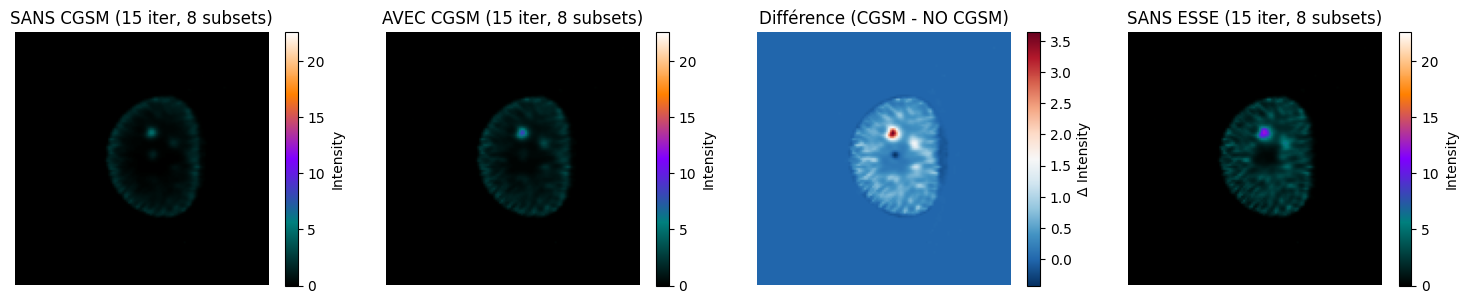


=== Comparaison AVEC vs SANS CGSM ===
AVEC CGSM  - Mean: 0.056, Std: 0.305, Max: 28.277
SANS CGSM  - Mean: 0.038, Std: 0.230, Max: 25.511
Différence - Mean abs: 0.018, Max abs: 5.535
% de différence (relative au max): 19.6%


In [48]:
# Comparaison visuelle : AVEC vs SANS CGSM

slice_idx = recon.shape[-1] // 2
vmax_comum = max(recon.max().item(), reconCGSM.max().item()) * 0.8

fig, axes = plt.subplots(1, 4, figsize=(15, 3))

# SANS CGSM
im1 = axes[0].imshow(recon[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_comum, origin='lower')
axes[0].set_title(f'SANS CGSM ({nb_iter} iter, {nb_subset} subsets)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Intensity')

# AVEC CGSM
im2 = axes[1].imshow(reconCGSM[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_comum, origin='lower')
axes[1].set_title(f'AVEC CGSM ({nb_iter} iter, {nb_subset} subsets)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Intensity')

# DIFFÉRENCE
diff = reconCGSM - recon
im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower')
axes[2].set_title('Différence (CGSM - NO CGSM)')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

im4 = axes[3].imshow(recon_no_esse[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_comum, origin='lower')
axes[3].set_title(f'SANS ESSE ({nb_iter} iter, {nb_subset} subsets)')
axes[3].axis('off')
plt.colorbar(im4, ax=axes[3], label='Intensity')

plt.tight_layout()
plt.show()

# Statistiques
print(f"\n=== Comparaison AVEC vs SANS CGSM ===")
print(f"AVEC CGSM  - Mean: {reconCGSM.mean():.3f}, Std: {reconCGSM.std():.3f}, Max: {reconCGSM.max():.3f}")
print(f"SANS CGSM  - Mean: {recon.mean():.3f}, Std: {recon.std():.3f}, Max: {recon.max():.3f}")
print(f"Différence - Mean abs: {diff.abs().mean():.3f}, Max abs: {diff.abs().max():.3f}")
print(f"% de différence (relative au max): {(diff.abs().max() / reconCGSM.max() * 100):.1f}%")

In [49]:
def run_dot_product_test(model, device='cpu'):
    """
    Vérifie l'égalité <H(x), y> = <x, H*(y)> pour l'opérateur ESSE.
    """
    # 1. Préparation des données aléatoires
    # On utilise la forme paddée pour être cohérent avec les FFT du modèle
    shape = model.object_meta.padded_shape
    
    # x : Un objet (activité) aléatoire
    x = torch.randn(shape, device=device, dtype=torch.float32)
    
    # v1, v2, v3 : Volumes de "résidus" ou d'erreur aléatoires
    v1 = torch.randn(shape, device=device, dtype=torch.float32)
    v2 = torch.randn(shape, device=device, dtype=torch.float32)
    v3 = torch.randn(shape, device=device, dtype=torch.float32)

    # --- SENS DIRECT (Forward) ---
    # prepare_iteration calcule les 3 volumes convolués I1, I2, I3
    model.prepare_iteration(x)
    I1, I2, I3 = model.convolved_volumes

    # --- SENS INVERSE (Adjoint) ---
    # apply_adjoint calcule la redistribution de l'erreur S
    S = model.apply_adjoint(v1, v2, v3)

    # --- CALCUL DES PRODUITS SCALAIRES ---
    # Côté gauche (LHS) : Somme des (Images convoluées * Résidus correspondants)
    # Note : On respecte les signes de l'équation 9 (I1 - I2 + I3)
    lhs = torch.sum(I1 * v1) - torch.sum(I2 * v2) + torch.sum(I3 * v3)
    
    # Côté droit (RHS) : Somme de (Objet initial * Image de sensibilité S)
    rhs = torch.sum(x * S)

    # --- ANALYSE DU RÉSULTAT ---
    lhs_val, rhs_val = lhs.item(), rhs.item()
    rel_diff = abs(lhs_val - rhs_val) / max(abs(lhs_val), abs(rhs_val))

    print("-" * 30)
    print(f"LHS (<H(x), v>) : {lhs_val:.8e}")
    print(f"RHS (<x, H*(v)>) : {rhs_val:.8e}")
    print(f"Différence relative : {rel_diff:.2e}")
    print("-" * 30)

    if rel_diff < 1e-6:
        print("✅ TEST RÉUSSI : L'adjoint est mathématiquement exact.")
        return 1
    else:
        print("❌ TEST ÉCHOUÉ : L'adjoint est incorrect.")
        if not any(torch.is_complex(k) for k in model.kernels_fft):
             print("👉 Conseil : Vérifiez si vous avez bien utilisé torch.conj() dans apply_adjoint.")
        return 0


In [50]:
# a = [0, 0]
# for i in range(500):
#     if i % 50 == 0:
#         print(f"Test {i}/500")
#     a[run_dot_product_test(esse)] += 1
# print(a)

In [51]:
# sans_conj = [132, 368]
# print("sans_conj : ", sans_conj)
# print("Pas passé : ", sans_conj[0], sans_conj[0]/500 * 100, "%")
# print("Passé : ", sans_conj[1], sans_conj[1]/500 * 100, "%")

# print("avec_conj :", a)
# print("Pas passé : ", a[0], a[0]/500 * 100, "%")
# print("Passé : ", a[1], a[1]/500 * 100, "%")
